In [4]:
from pathlib import Path
import numpy as np
import pandas as pd

import os

import json

from nilearn.maskers import NiftiLabelsMasker
from neuroginius.atlas import Atlas #not strictly necessary, can use path to a parcellation atlas instead

movie_name = "AfterTheRain"


In [5]:
atlas = Atlas().from_name("schaefer200")
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize="zscore_sample")
masker.fit()

NiftiLabelsMasker(labels_img='/homes_unix/agillig/nilearn_data/schaefer_2018/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii.gz',
                  standardize='zscore_sample')

In [6]:
# data_path = Path("../../data/emofilm_fmri/derivatives/preprocessing/")
# out_dir = Path(f"../../data/emofilm_fmri/derivatives/parcellated_timeseries/{atlas.name}/{movie_name}")
# os.makedirs(out_dir, exist_ok=True)

# subjects_list = []
# for sub_idx in range(25):
#     sub_str = f"S{sub_idx+1:02d}"

#     files = list(
#         (data_path / f"sub-{sub_str}").glob(
#             f"ses-*/func/sub-{sub_str}_ses-*_task-{movie_name}_space-MNI_desc-ppres_bold.nii.gz"
#         )
#     )

#     if not files:
#         continue

#     file = files[0]  # or handle multiple matches

   
#     subjects_list.append(sub_str)
#     print(f"Processing {file}...")
#     parcellated_time_series = masker.transform(file)
    
#     save_path = out_dir / f"sub-{sub_str}_ses-3_task-{movie_name}_space-MNI_desc-ppres_bold_parcellated.tsv"

#     np.savetxt(save_path, parcellated_time_series)

#     event_timings_files = list(
#         (Path("../../data/emofilm_fmri") / f"sub-{sub_str}").glob(
#             f"ses-*/func/sub-{sub_str}_ses-*_task-scan_acq-{movie_name}_events.tsv"
#         )
#     )
#     working_dir = Path("../../data/emofilm/event_timings")
#     os.makedirs(working_dir, exist_ok=True)
#     event_timings = pd.read_csv(event_timings_files[0], sep="\t") if event_timings_files else None
#     event_timings.to_csv(working_dir / f"sub-{sub_str}_{movie_name}_events.tsv", index=False)


In [7]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
from multiprocessing import Pool, cpu_count


data_path = Path("../../data/emofilm_fmri/derivatives/preprocessing/")
out_dir = Path(
    f"../../data/emofilm_fmri/derivatives/parcellated_timeseries/{atlas.name}/{movie_name}"
)
out_dir.mkdir(parents=True, exist_ok=True)

working_dir = Path("../../data/emofilm/event_timings")
working_dir.mkdir(parents=True, exist_ok=True)


def process_subject(sub_idx):
    sub_str = f"S{sub_idx + 1:02d}"

    files = list(
        (data_path / f"sub-{sub_str}").glob(
            f"ses-*/func/sub-{sub_str}_ses-*_task-{movie_name}_space-MNI_desc-ppres_bold.nii.gz"
        )
    )

    if not files:
        print(f"No files found for {sub_str}")
        return None

    file = files[0]
    print(f"Processing {file}")

    # expensive step
    parcellated_time_series = masker.transform(file)

    save_path = (
        out_dir
        / f"sub-{sub_str}_ses-3_task-{movie_name}_space-MNI_desc-ppres_bold_parcellated.tsv"
    )
    np.savetxt(save_path, parcellated_time_series)

    event_timings_files = list(
        (Path("../../data/emofilm_fmri") / f"sub-{sub_str}").glob(
            f"ses-*/func/sub-{sub_str}_ses-*_task-scan_acq-{movie_name}_events.tsv"
        )
    )

    if event_timings_files:
        event_timings = pd.read_csv(event_timings_files[0], sep="\t")
        event_timings.to_csv(
            working_dir / f"sub-{sub_str}_{movie_name}_events.tsv",
            index=False,
        )

    return sub_str


if __name__ == "__main__":
    n_jobs = min(25, cpu_count())

    with Pool(processes=n_jobs) as pool:
        subjects_list = [
            s for s in pool.map(process_subject, range(25))
            if s is not None
        ]

    print("Finished:", subjects_list)

Processing ../../data/emofilm_fmri/derivatives/preprocessing/sub-S02/ses-1/func/sub-S02_ses-1_task-AfterTheRain_space-MNI_desc-ppres_bold.nii.gzProcessing ../../data/emofilm_fmri/derivatives/preprocessing/sub-S03/ses-3/func/sub-S03_ses-3_task-AfterTheRain_space-MNI_desc-ppres_bold.nii.gzNo files found for S12Processing ../../data/emofilm_fmri/derivatives/preprocessing/sub-S01/ses-2/func/sub-S01_ses-2_task-AfterTheRain_space-MNI_desc-ppres_bold.nii.gzProcessing ../../data/emofilm_fmri/derivatives/preprocessing/sub-S06/ses-2/func/sub-S06_ses-2_task-AfterTheRain_space-MNI_desc-ppres_bold.nii.gzProcessing ../../data/emofilm_fmri/derivatives/preprocessing/sub-S04/ses-3/func/sub-S04_ses-3_task-AfterTheRain_space-MNI_desc-ppres_bold.nii.gzProcessing ../../data/emofilm_fmri/derivatives/preprocessing/sub-S08/ses-2/func/sub-S08_ses-2_task-AfterTheRain_space-MNI_desc-ppres_bold.nii.gzProcessing ../../data/emofilm_fmri/derivatives/preprocessing/sub-S10/ses-4/func/sub-S10_ses-4_task-AfterTheRain_sp

In [8]:
event_timings

,onset,duration,trial_type
0,2.872457,89.981560,rest
1,93.965603,496.082568,film
2,591.096270,89.967645,rest


In [9]:
behav_data_path = Path("../../data/emofilm_annotation/derivatives/")
os.listdir(behav_data_path)


with open(behav_data_path / f"Annot_{movie_name}_stim.json", "r") as f:
    metadata = json.load(f)

behav_data = pd.read_csv(behav_data_path / f"Annot_{movie_name}_stim.tsv.gz",
    compression="gzip",
    sep="\t",
    header=None
    )

behav_data.columns = metadata["Columns"]


working_dir = Path("../../data/emofilm/")
behav_data.to_csv(working_dir / f"Annot_{movie_name}_stim.csv", index=False)


In [10]:
behav_data.head()

,Standards,PleasantSelf,SocialNorms,PleasantOther,GoalsOther,Controlled,Predictable,Suddenly,Agent,Urgency,...,Disgust,Happiness,Fear,Regard,Anxiety,Satisfaction,Pride,Surprise,Love,Sad
0,0.105069,0.453663,0.237408,0.424665,-0.388207,0.097503,1.862368,-0.079510,-0.418996,-0.208150,...,-0.043765,0.471479,-0.308988,-0.133703,-0.855552,0.246556,0.328818,-0.295054,0.333593,-0.470214
1,0.024357,0.449826,0.238010,0.424665,-0.388207,0.097503,1.747290,-0.134586,-0.418996,-0.737396,...,-0.031966,0.471479,-0.308988,-0.133703,-0.856457,0.246556,0.328818,-0.295054,0.333593,-0.470214
2,0.070704,0.414445,0.293824,0.424665,-0.291213,0.097503,1.504896,-0.188682,-0.418996,-0.999275,...,-0.031966,0.471479,-0.588825,-0.133703,-1.210829,0.246556,0.328818,-0.295054,0.333593,-0.470214
3,0.105296,0.413923,0.292980,0.406338,-0.101414,0.097503,1.435084,-0.296824,-0.418996,-1.084361,...,-0.031966,0.432859,-0.873184,-0.133703,-1.495191,0.246556,0.328818,-0.295054,0.179468,-0.470214
4,-0.019593,0.413923,0.371977,0.218044,0.058179,0.097503,1.354356,-0.425361,-0.418996,-1.121516,...,-0.402893,0.326432,-0.873184,-0.133703,-1.831240,0.217631,0.328818,-0.295054,-0.612967,-0.469630


create appropriate data structure for training: list of np arrays of shape (n_timepoints x n_regions)

In [11]:
X = []
subjects_list = []
for sub_idx in range(25):
    sub_str = f"S{sub_idx+1:02d}"

    file = out_dir / f"sub-{sub_str}_ses-3_task-{movie_name}_space-MNI_desc-ppres_bold_parcellated.tsv"


    if not os.path.exists(file):
        continue

    tmp_array = np.loadtxt(file)
    X.append(tmp_array)
    


In [14]:
np.savez(working_dir/f"{movie_name}_{atlas.name}_parcellated_timeseries.npz",*X)

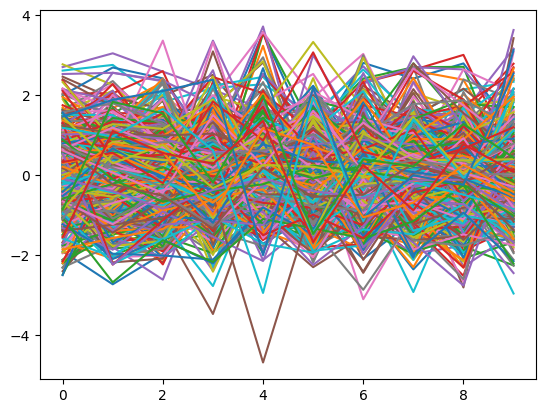

In [21]:
import matplotlib.pyplot as plt
plt.plot(X[0].T[:10])
plt.show()